# Team 11 — Sentiment Analysis & Rating Prediction
### Recipe Reviews Dataset | Task 1: Sentiment Classification (Logistic Regression)


In [1]:
import subprocess, sys

packages = [
    'pandas', 'numpy', 'scikit-learn', 'nltk',
    'beautifulsoup4', 'matplotlib', 'seaborn', 'wordcloud', 'scipy'
]

print('Installing / verifying packages...')
for pkg in packages:
    try:
        __import__(pkg.replace('-', '_'))
        print(f'  [OK] {pkg}')
    except ImportError:
        print(f'  Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

print('\n✓ All dependencies ready!')


Installing / verifying packages...
  [OK] pandas
  [OK] numpy
  Installing scikit-learn...
  [OK] nltk
  Installing beautifulsoup4...
  [OK] matplotlib
  [OK] seaborn
  [OK] wordcloud
  [OK] scipy

✓ All dependencies ready!


In [2]:
import re, html, os, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from bs4 import BeautifulSoup
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.tag import pos_tag
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score
)

import nltk
for _item in ['punkt_tab', 'stopwords', 'wordnet', 'averaged_perceptron_tagger_eng']:
    try:
        nltk.data.find(
            f'tokenizers/{_item}' if 'punkt' in _item else
            f'taggers/{_item}'    if 'tagger' in _item else
            f'corpora/{_item}'
        )
    except LookupError:
        nltk.download(_item, quiet=True)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
print('✓ All imports and NLTK data ready!')


✓ All imports and NLTK data ready!


## Phase 1 — Text Cleaning

In [3]:
class TextCleaner:
    """5-step text cleaning pipeline tailored for recipe reviews."""

    def __init__(self):
        self.lemmatizer = WordNetLemmatizer()
        # Keep sentiment-bearing negations; drop recipe-domain neutral terms
        self.stopwords = (
            set(stopwords.words('english'))
            - {'no', 'not', 'very', 'never', 'nor', 'only', 'should'}
        )
        self.stopwords |= {
            'recipe', 'minutes', 'degrees', 'ingredients', 'oven',
            'cup', 'cups', 'tsp', 'tbsp', 'oz', 'lb', 'gram',
            'ml', 'serving', 'servings', 'prep'
        }

    @staticmethod
    def _get_wordnet_pos(treebank_tag):
        mapping = {'J': wordnet.ADJ, 'V': wordnet.VERB,
                   'N': wordnet.NOUN, 'R': wordnet.ADV}
        return mapping.get(treebank_tag[0], wordnet.NOUN)

    def clean_text(self, text):
        if not isinstance(text, str) or not text.strip():
            return ''

        # Step 1 — HTML decode and tag removal
        text = BeautifulSoup(text, 'html.parser').get_text()
        text = html.unescape(text)

        # Step 2 — Lowercase and keep only letters / spaces
        text = text.lower()
        text = re.sub(r'[^a-z\s]', ' ', text)
        text = re.sub(r'\s+', ' ', text).strip()

        # Step 3 — Tokenise
        tokens = word_tokenize(text)

        # Step 4 — POS-aware lemmatisation
        pos_tags = pos_tag(tokens)
        tokens = [
            self.lemmatizer.lemmatize(tok, self._get_wordnet_pos(pos))
            for tok, pos in pos_tags
        ]

        # Step 5 — Stopword removal (min token length 2)
        tokens = [t for t in tokens if t not in self.stopwords and len(t) > 1]

        return ' '.join(tokens)


## Phase 2 — Metadata Engineering

In [4]:
class MetadataEngineer:
    """Temporal decomposition and numerical scaling for metadata columns."""

    def __init__(self):
        self.scaler = StandardScaler()
        self.fitted = False

    def engineer_metadata(self, df, fit=False):
        df = df.copy()

        # Unix timestamp -> cyclical month and day-of-week features
        dt  = pd.to_datetime(df['created_at'], unit='s')
        month = dt.dt.month
        dow   = dt.dt.dayofweek

        df['month_sin']       = np.sin(2 * np.pi * month / 12)
        df['month_cos']       = np.cos(2 * np.pi * month / 12)
        df['day_of_week_sin'] = np.sin(2 * np.pi * dow / 7)
        df['day_of_week_cos'] = np.cos(2 * np.pi * dow / 7)

        # Scale numerical metadata columns
        num_cols = ['user_reputation', 'reply_count', 'thumbs_up', 'thumbs_down']
        if fit:
            df[num_cols] = self.scaler.fit_transform(df[num_cols])
            self.fitted = True
        else:
            if not self.fitted:
                raise RuntimeError('Fit MetadataEngineer on training data first.')
            df[num_cols] = self.scaler.transform(df[num_cols])

        return df


## Phase 3 — Feature Fusion (TF-IDF + Metadata)

In [5]:
class RecipeReviewPreprocessor:
    """
    Orchestrates Phases 1 -> 2 -> 3 and returns only the feature matrix X.

    Labels (y) are extracted separately BEFORE calling apply_all_phases:
      Task 1:  df['sentiment']  (Positive / Neutral / Negative)

    This prevents the original bug where df['stars'] was silently used as
    the classification target while sentiment labels went unused.
    """

    def __init__(self):
        self.text_cleaner       = TextCleaner()
        self.metadata_engineer  = MetadataEngineer()
        self.column_transformer = None   # fitted on training split only

    def load_data(self, filepath):
        df = pd.read_csv(filepath)
        print(f'Loaded shape          : {df.shape}')
        df = df[df['stars'] != 0].reset_index(drop=True)
        print(f'After dropping stars=0: {df.shape}')
        return df

    def apply_all_phases(self, df_input, is_training_set=False):
        """
        Returns X (scipy sparse matrix): TF-IDF features + scaled metadata.
        Always fit=True only for the training split.
        """
        df  = df_input.copy()
        tag = 'Training' if is_training_set else 'Val / Test'

        # -- Phase 1: Text Cleaning ------------------------------------------
        print(f'\n{"="*65}')
        print(f'  PHASE 1 — Text Cleaning   [{tag}]')
        print(f'{"="*65}')
        df['text_cleaned'] = df['text'].apply(self.text_cleaner.clean_text)
        print('  ✓ Done')

        # -- Phase 2: Metadata Engineering -----------------------------------
        print(f'\n{"="*65}')
        print(f'  PHASE 2 — Metadata Engineering   [{tag}]')
        print(f'{"="*65}')
        df = self.metadata_engineer.engineer_metadata(df, fit=is_training_set)
        print('  ✓ Done')

        # -- Phase 3: Feature Fusion (TF-IDF + numerical passthrough) --------
        print(f'\n{"="*65}')
        print(f'  PHASE 3 — Feature Fusion   [{tag}]')
        print(f'{"="*65}')

        feature_cols = [
            'text_cleaned',
            'user_reputation', 'reply_count', 'thumbs_up', 'thumbs_down',
            'month_sin', 'month_cos', 'day_of_week_sin', 'day_of_week_cos'
        ]
        X_pre = df[feature_cols]

        if is_training_set:
            self.column_transformer = ColumnTransformer(
                transformers=[
                    ('text', TfidfVectorizer(
                        ngram_range=(1, 3),
                        max_features=10_000,
                        min_df=2,
                        max_df=0.95,
                        lowercase=False,
                        stop_words=None
                    ), 'text_cleaned'),
                    ('num', 'passthrough',
                     ['user_reputation', 'reply_count', 'thumbs_up', 'thumbs_down',
                      'month_sin', 'month_cos', 'day_of_week_sin', 'day_of_week_cos'])
                ],
                remainder='drop'
            )
            X = self.column_transformer.fit_transform(X_pre)
            print(f'  ✓ Fitted + transformed.  X shape: {X.shape}')
        else:
            if self.column_transformer is None:
                raise RuntimeError('Fit the preprocessor on training data first.')
            X = self.column_transformer.transform(X_pre)
            print(f'  ✓ Transformed.  X shape: {X.shape}')

        return X


## Data Loading & Sentiment Label Creation

In [6]:
# Update DATA_PATH if the CSV is not in the current working directory
DATA_PATH = os.path.join(os.getcwd(), 'recipe_reviews.csv')

preprocessor = RecipeReviewPreprocessor()
df_raw = preprocessor.load_data(DATA_PATH)

# ── Derive sentiment labels from star ratings (Task 1 target) ─────────────
#   1-2 stars  ->  Negative
#     3 stars  ->  Neutral
#   4-5 stars  ->  Positive
SENTIMENT_MAP = {1: 'Negative', 2: 'Negative',
                 3: 'Neutral',
                 4: 'Positive', 5: 'Positive'}

df_raw['sentiment'] = df_raw['stars'].map(SENTIMENT_MAP)

print(f'\nSentiment distribution:\n{df_raw["sentiment"].value_counts()}')
print(f'\nStar rating distribution:\n{df_raw["stars"].value_counts().sort_index()}')
df_raw[['recipe_name', 'stars', 'sentiment', 'best_score', 'text']].head()


Loaded shape          : (18182, 15)
After dropping stars=0: (16486, 15)

Sentiment distribution:
sentiment
Positive    15484
Negative      512
Neutral       490
Name: count, dtype: int64

Star rating distribution:
stars
1      280
2      232
3      490
4     1655
5    13829
Name: count, dtype: int64


,recipe_name,stars,sentiment,best_score,text
0,Creamy White Chili,5,Positive,527,"I tweaked it a little, removed onions because ..."
1,Creamy White Chili,5,Positive,724,Bush used to have a white chili bean and it ma...
2,Creamy White Chili,5,Positive,710,I have a very complicated white chicken chili ...
3,Creamy White Chili,5,Positive,518,amazing! my boyfriend loved it so much! going ...
4,Creamy White Chili,5,Positive,833,Wow!!! This recipe is excellent as written!! ...


## Exploratory Data Analysis

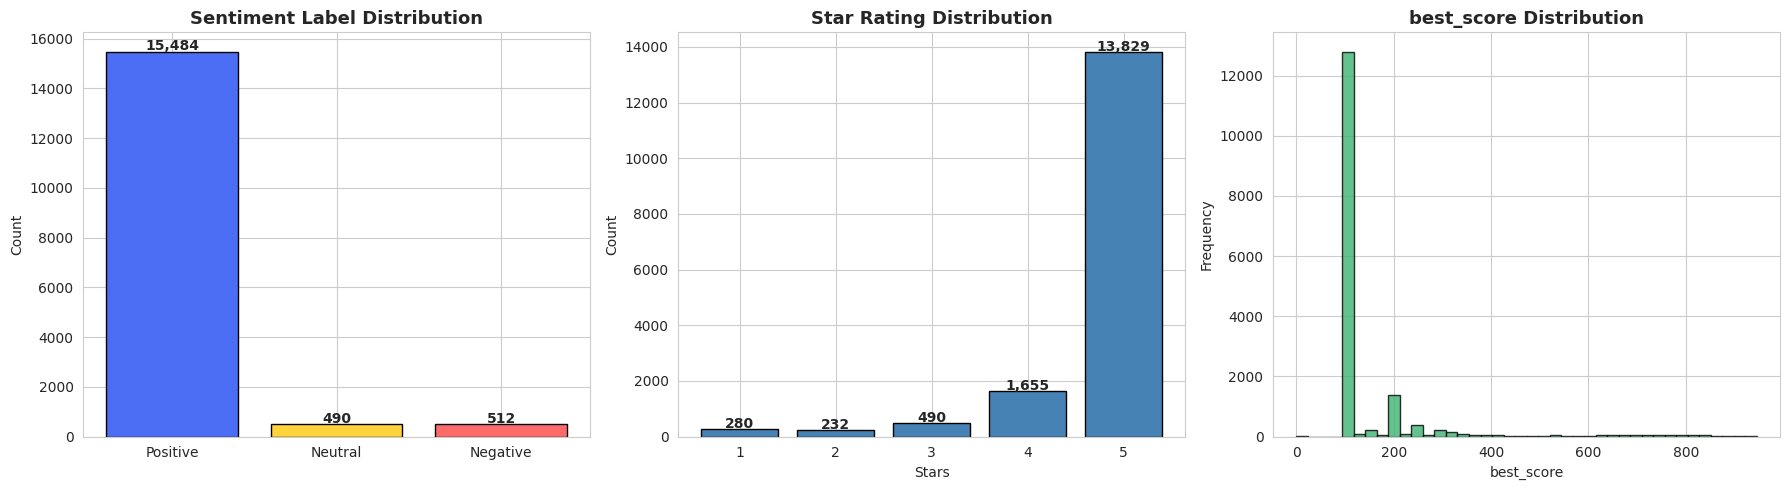


best_score stats:
count    16486.00
mean       151.07
std        137.32
min          0.00
25%        100.00
50%        100.00
75%        100.00
max        946.00
Name: best_score, dtype: float64


In [7]:
SENT_COLORS = {'Positive': '#4c6ef5', 'Neutral': '#ffd43b', 'Negative': '#ff6b6b'}
ORDER = ['Positive', 'Neutral', 'Negative']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Sentiment bar chart
counts = df_raw['sentiment'].value_counts().reindex(ORDER)
axes[0].bar(counts.index, counts.values,
            color=[SENT_COLORS[s] for s in counts.index], edgecolor='black')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')
axes[0].set_title('Sentiment Label Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')

# Star rating bar chart
star_counts = df_raw['stars'].value_counts().sort_index()
axes[1].bar(star_counts.index, star_counts.values,
            color='steelblue', edgecolor='black')
for i, v in enumerate(star_counts.values):
    axes[1].text(star_counts.index[i], v + 30, f'{v:,}', ha='center', fontweight='bold')
axes[1].set_title('Star Rating Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Stars')
axes[1].set_ylabel('Count')

# best_score distribution
axes[2].hist(df_raw['best_score'], bins=40, color='mediumseagreen',
             edgecolor='black', alpha=0.8)
axes[2].set_title('best_score Distribution', fontsize=13, fontweight='bold')
axes[2].set_xlabel('best_score')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('01_eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nbest_score stats:')
print(df_raw['best_score'].describe().round(2))


Text Length Statistics:
       text_length  word_count
count      16486.0     16486.0
mean         207.4        38.5
std          174.8        32.6
min            1.0         0.0
25%           91.0        17.0
50%          165.0        30.0
75%          272.0        50.8
max         2742.0       499.0


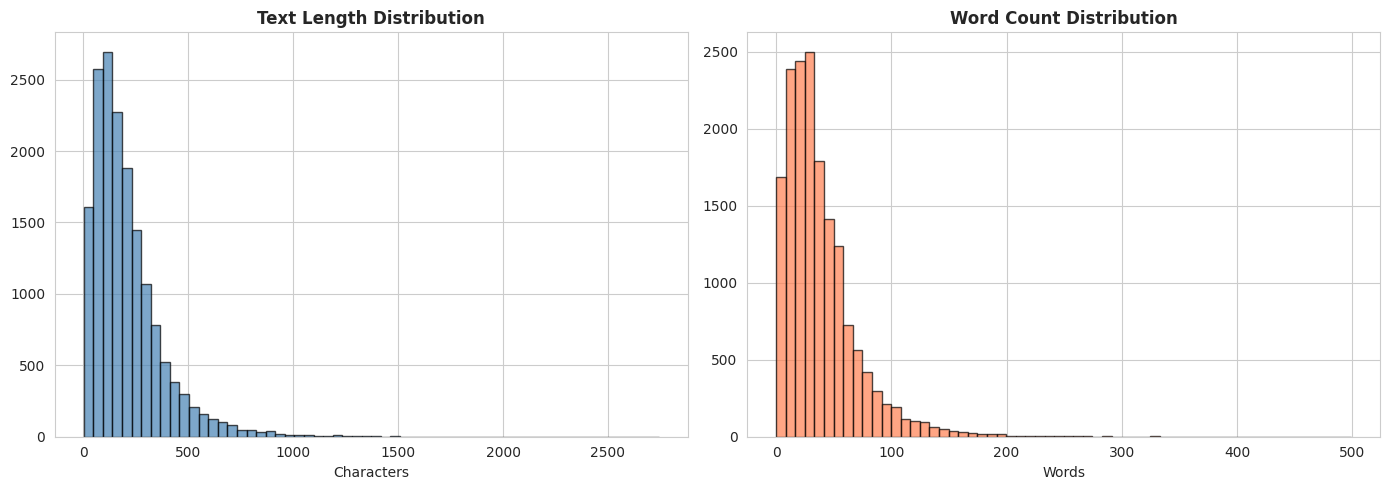

In [8]:
# Text length and word count
df_raw['text_length'] = df_raw['text'].astype(str).apply(len)
df_raw['word_count']  = df_raw['text'].astype(str).apply(lambda x: len(x.split()))

print('Text Length Statistics:')
print(df_raw[['text_length', 'word_count']].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df_raw['text_length'], bins=60, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Characters')
axes[0].set_title('Text Length Distribution', fontweight='bold')
axes[1].hist(df_raw['word_count'], bins=60, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Words')
axes[1].set_title('Word Count Distribution', fontweight='bold')
plt.tight_layout()
plt.savefig('02_text_lengths.png', dpi=150, bbox_inches='tight')
plt.show()


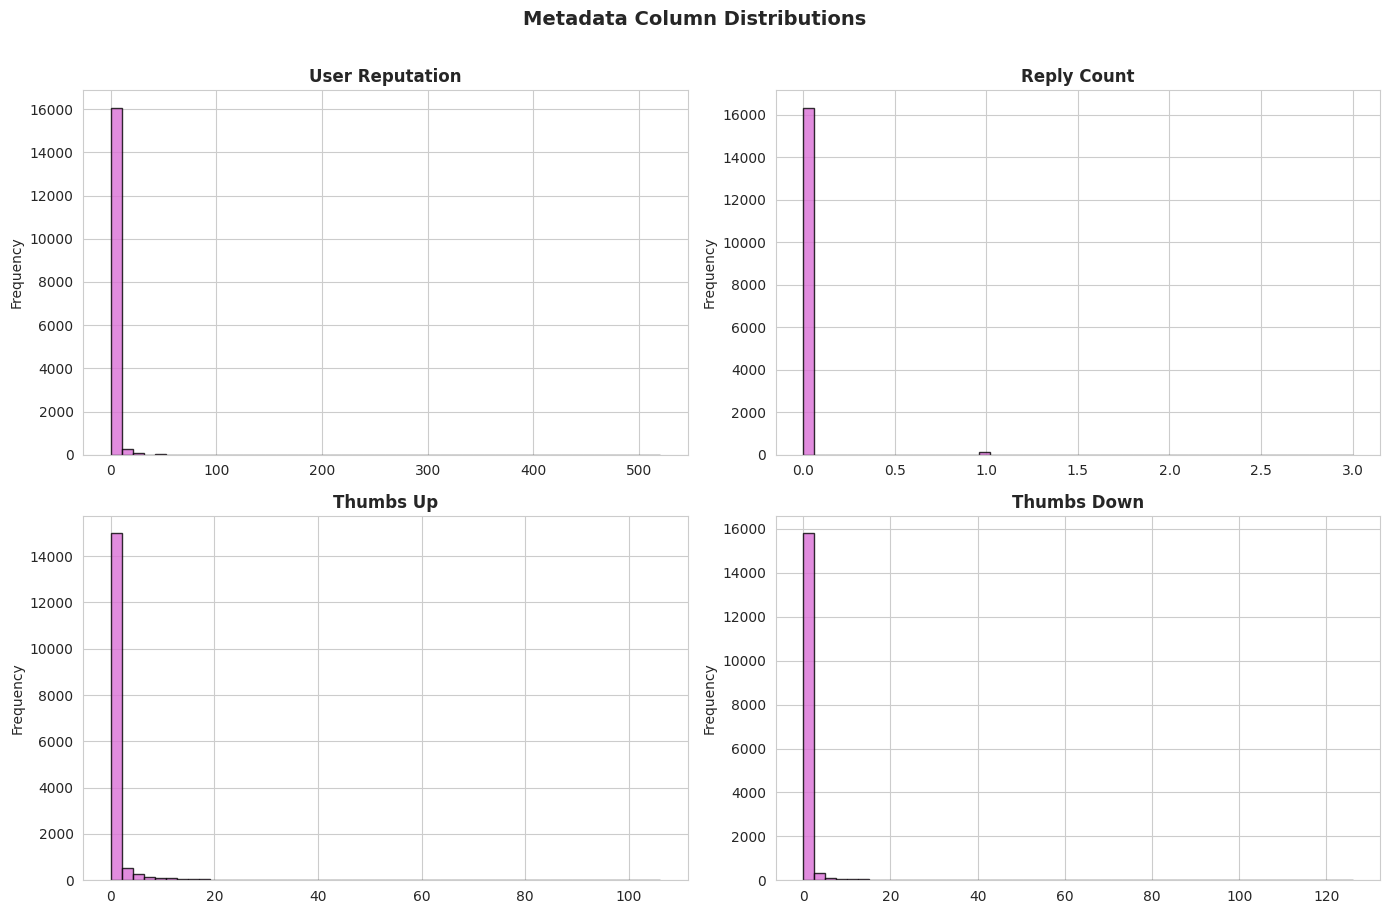

In [9]:
# Metadata column distributions
meta_cols = ['user_reputation', 'reply_count', 'thumbs_up', 'thumbs_down']
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col in zip(axes.flatten(), meta_cols):
    ax.hist(df_raw[col], bins=50, color='orchid', edgecolor='black', alpha=0.8)
    ax.set_title(col.replace('_', ' ').title(), fontweight='bold')
    ax.set_ylabel('Frequency')
plt.suptitle('Metadata Column Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('03_metadata_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


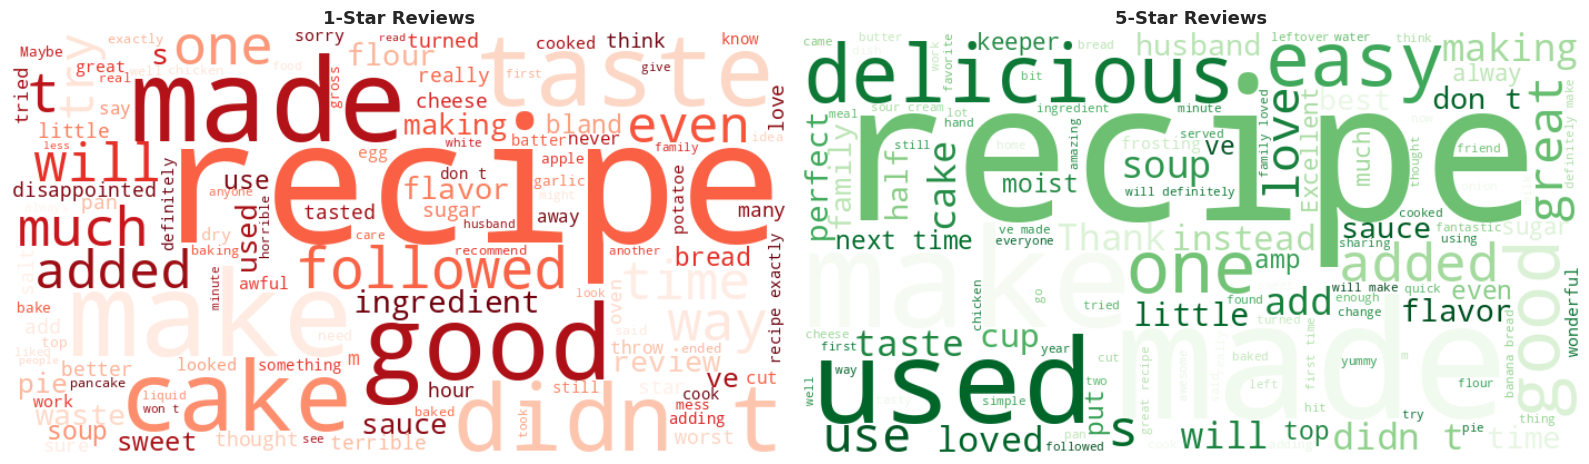

In [10]:
# Word clouds: 1-star vs 5-star raw text
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, star, cmap in zip(axes, [1, 5], ['Reds', 'Greens']):
    combined = ' '.join(df_raw[df_raw['stars'] == star]['text'].astype(str))
    wc = WordCloud(width=700, height=380, background_color='white',
                   colormap=cmap, max_words=120).generate(combined)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{star}-Star Reviews', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('04_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()


## Train / Validation / Test Split (70 – 15 – 15)

In [11]:
df_train, df_temp = train_test_split(
    df_raw, test_size=0.30, random_state=42, stratify=df_raw['stars']
)
df_val, df_test = train_test_split(
    df_temp, test_size=0.50, random_state=42, stratify=df_temp['stars']
)

print(f'Train : {df_train.shape}')
print(f'Val   : {df_val.shape}')
print(f'Test  : {df_test.shape}')

# ── Extract sentiment labels BEFORE preprocessing (indices aligned) ─────────
# Task 1: 3-class sentiment labels
y_sent_train = df_train['sentiment'].values
y_sent_val   = df_val['sentiment'].values
y_sent_test  = df_test['sentiment'].values

print(f'\nSentiment class counts (train): {dict(pd.Series(y_sent_train).value_counts())}')
print(f'Stratification check (val)    : {dict(pd.Series(y_sent_val).value_counts())}')


Train : (11540, 18)
Val   : (2473, 18)
Test  : (2473, 18)

Sentiment class counts (train): {'Positive': np.int64(10839), 'Negative': np.int64(358), 'Neutral': np.int64(343)}
Stratification check (val)    : {'Positive': np.int64(2323), 'Negative': np.int64(77), 'Neutral': np.int64(73)}


## Apply Preprocessing Pipeline

In [12]:
# Fit ONLY on training data; transform all three splits with the fitted objects
X_train = preprocessor.apply_all_phases(df_train, is_training_set=True)
X_val   = preprocessor.apply_all_phases(df_val,   is_training_set=False)
X_test  = preprocessor.apply_all_phases(df_test,  is_training_set=False)

print('\n' + '='*65)
print('PREPROCESSING COMPLETE')
print('='*65)
print(f'X_train : {X_train.shape}')
print(f'X_val   : {X_val.shape}')
print(f'X_test  : {X_test.shape}')



  PHASE 1 — Text Cleaning   [Training]
  ✓ Done

  PHASE 2 — Metadata Engineering   [Training]
  ✓ Done

  PHASE 3 — Feature Fusion   [Training]
  ✓ Fitted + transformed.  X shape: (11540, 10008)

  PHASE 1 — Text Cleaning   [Val / Test]
  ✓ Done

  PHASE 2 — Metadata Engineering   [Val / Test]
  ✓ Done

  PHASE 3 — Feature Fusion   [Val / Test]
  ✓ Transformed.  X shape: (2473, 10008)

  PHASE 1 — Text Cleaning   [Val / Test]
  ✓ Done

  PHASE 2 — Metadata Engineering   [Val / Test]
  ✓ Done

  PHASE 3 — Feature Fusion   [Val / Test]
  ✓ Transformed.  X shape: (2473, 10008)

PREPROCESSING COMPLETE
X_train : (11540, 10008)
X_val   : (2473, 10008)
X_test  : (2473, 10008)


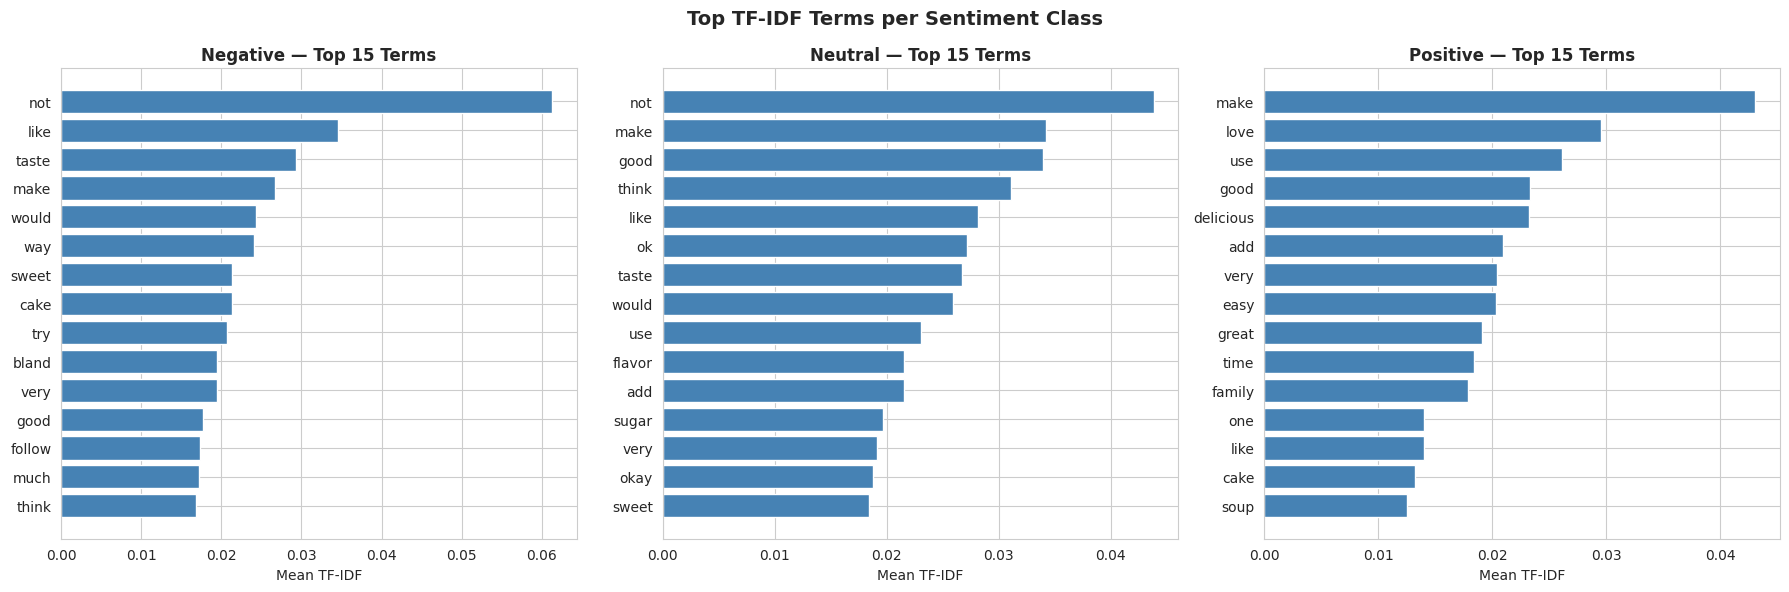

In [13]:
# Top TF-IDF terms per sentiment class
tfidf_tf   = preprocessor.column_transformer.named_transformers_['text']
feat_names = np.array(tfidf_tf.get_feature_names_out())

sent_classes = ['Negative', 'Neutral', 'Positive']
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, cls in zip(axes, sent_classes):
    idx        = np.where(y_sent_train == cls)[0]
    mean_tfidf = np.asarray(X_train[idx, :10_000].mean(axis=0)).flatten()
    top_idx    = np.argsort(-mean_tfidf)[:15]
    ax.barh(feat_names[top_idx][::-1], mean_tfidf[top_idx][::-1], color='steelblue')
    ax.set_title(f'{cls} — Top 15 Terms', fontweight='bold')
    ax.set_xlabel('Mean TF-IDF')

plt.suptitle('Top TF-IDF Terms per Sentiment Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('05_tfidf_top_terms.png', dpi=150, bbox_inches='tight')
plt.show()


In [14]:
# ── Logistic Regression with GridSearchCV ────────────────────────────────────
lr = LogisticRegression(
    class_weight='balanced',   # handles Positive >> Neutral/Negative imbalance
    max_iter=500,
    random_state=42
)

param_grid = {
    'C'      : [0.1, 1, 10],
    'penalty': ['l2'],
    'solver' : ['saga', 'liblinear']  # saga: large sparse; liblinear: small/medium
}

gs = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    cv=3,
    scoring='f1_macro',    # macro-F1 penalises poor minority-class recall
    n_jobs=-1,
    verbose=2
)

print('Starting Logistic Regression Grid Search...')
gs.fit(X_train, y_sent_train)

print('\n✓ Grid Search complete!')
print(f'Best params    : {gs.best_params_}')
print(f'Best CV F1-macro : {gs.best_score_:.4f}')

best_lr = gs.best_estimator_


Starting Logistic Regression Grid Search...
Fitting 3 folds for each of 6 candidates, totalling 18 fits

✓ Grid Search complete!
Best params    : {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV F1-macro : 0.5770


In [15]:
# ── Evaluation on all splits ─────────────────────────────────────────────────
y_pred_train = best_lr.predict(X_train)
y_pred_val   = best_lr.predict(X_val)
y_pred_test  = best_lr.predict(X_test)

print(f'Train Accuracy : {accuracy_score(y_sent_train, y_pred_train):.4f}')
print(f'Val   Accuracy : {accuracy_score(y_sent_val,   y_pred_val):.4f}')
print(f'Test  Accuracy : {accuracy_score(y_sent_test,  y_pred_test):.4f}')

print('\n── Classification Report (Validation) ──')
print(classification_report(y_sent_val, y_pred_val,
      target_names=['Negative', 'Neutral', 'Positive']))

print('\n── Classification Report (Test) ──')
print(classification_report(y_sent_test, y_pred_test,
      target_names=['Negative', 'Neutral', 'Positive']))


Train Accuracy : 0.9961
Val   Accuracy : 0.9495
Test  Accuracy : 0.9523

── Classification Report (Validation) ──
              precision    recall  f1-score   support

    Negative       0.68      0.49      0.57        77
     Neutral       0.38      0.26      0.31        73
    Positive       0.97      0.99      0.98      2323

    accuracy                           0.95      2473
   macro avg       0.68      0.58      0.62      2473
weighted avg       0.94      0.95      0.94      2473


── Classification Report (Test) ──
              precision    recall  f1-score   support

    Negative       0.62      0.52      0.57        77
     Neutral       0.44      0.28      0.34        74
    Positive       0.97      0.99      0.98      2322

    accuracy                           0.95      2473
   macro avg       0.68      0.60      0.63      2473
weighted avg       0.94      0.95      0.95      2473



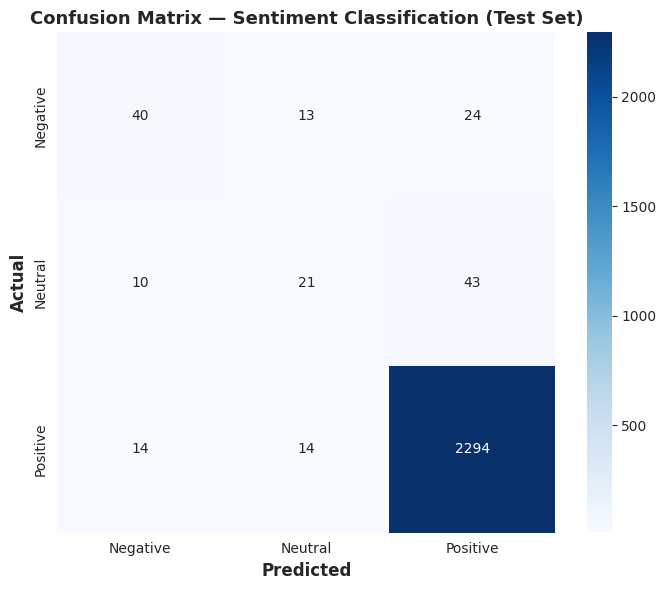

✓ Model saved -> model_lr_sentiment.pkl


In [16]:
# ── Confusion matrix (Test set) ──────────────────────────────────────────────
cm = confusion_matrix(y_sent_test, y_pred_test,
                      labels=['Negative', 'Neutral', 'Positive'])
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.xlabel('Predicted', fontsize=12, fontweight='bold')
plt.ylabel('Actual',    fontsize=12, fontweight='bold')
plt.title('Confusion Matrix — Sentiment Classification (Test Set)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('06_confusion_matrix_lr.png', dpi=150, bbox_inches='tight')
plt.show()

# Save model
with open('model_lr_sentiment.pkl', 'wb') as f:
    pickle.dump(best_lr, f)
print('✓ Model saved -> model_lr_sentiment.pkl')
